<center><img src="images/clothing.jpg"></center>

Welcome to the world of e-commerce, where customer feedback is a goldmine of insights! In this project, you'll dive into the Women's Clothing E-Commerce Reviews dataset, focusing on the 'Review Text' column filled with direct customer opinions.

Your mission is to use text embeddings and Python to analyze these reviews, uncover underlying themes, and understand customer sentiments. This analysis will help improve customer service and product offerings.

## The Data

You will be working with a dataset specifically focusing on customer reviews. Below is the data dictionary for the relevant field:

## womens_clothing_e-commerce_reviews.csv

| Column        | Description                           |
|---------------|---------------------------------------|
| `'Review Text'` | Textual feedback provided by customers about their shopping experience and product quality. |

Armed with access to powerful embedding API services, you will process the reviews, extract meaningful insights, and present your findings.

Let's get started!

## Install useful libraries

In [51]:
# Run this cell to install ChromaDB if desired
try:
    assert version('chromadb') == '0.4.17'
except:
    !pip install chromadb==0.4.17
try:
    assert version('pysqlite3') == '0.5.2'
except:
    !pip install pysqlite3-binary==0.5.2
__import__('pysqlite3')
import sys
sys.modules['sqlite3'] = sys.modules.pop('pysqlite3')
import chromadb
import os

Defaulting to user installation because normal site-packages is not writeable

[notice] A new release of pip is available: 25.0.1 -> 26.0.1
[notice] To update, run: python3 -m pip install --upgrade pip
Defaulting to user installation because normal site-packages is not writeable

[notice] A new release of pip is available: 25.0.1 -> 26.0.1
[notice] To update, run: python3 -m pip install --upgrade pip


## Load the dataset
Load data and perform basic data checks to ensure you are using relevant data for the analysis

In [52]:
# Load the dataset
import pandas as pd
reviews = pd.read_csv("womens_clothing_e-commerce_reviews.csv")

# Display the first few entries
reviews.head()

,Review ID,Clothing ID,Age,Title,Review Text,Rating,Recommended IND,Positive Feedback Count,Division Name,Department Name,Class Name
0,0,767,33,NaN,Absolutely wonderful - silky and sexy and comf...,4,1,0,Initmates,Intimate,Intimates
1,1,1080,34,NaN,Love this dress! it's sooo pretty. i happene...,5,1,4,General,Dresses,Dresses
2,2,1077,60,Some major design flaws,I had such high hopes for this dress and reall...,3,0,0,General,Dresses,Dresses
3,3,1049,50,My favorite buy!,"I love, love, love this jumpsuit. it's fun, fl...",5,1,0,General Petite,Bottoms,Pants
4,4,847,47,Flattering shirt,This shirt is very flattering to all due to th...,5,1,6,General,Tops,Blouses


In [53]:
# Fixed code

from openai import OpenAI

# Instantiate the OpenAI client correctly
client = OpenAI()

# Assuming 'reviews' is a DataFrame, get the 'Review Text' column and drop NaNs
review_text = reviews['Review Text'].dropna()
EMBEDDING_MODEL= 'text-embedding-3-small'
def create_embeddings(review_text):
    responses = client.embeddings.create(
        model=EMBEDDING_MODEL,
        input=review_text.tolist()
    ).model_dump()
    embedding_list = [response['embedding'] for response in responses['data']]
    return embedding_list

embeddings= create_embeddings(review_text)

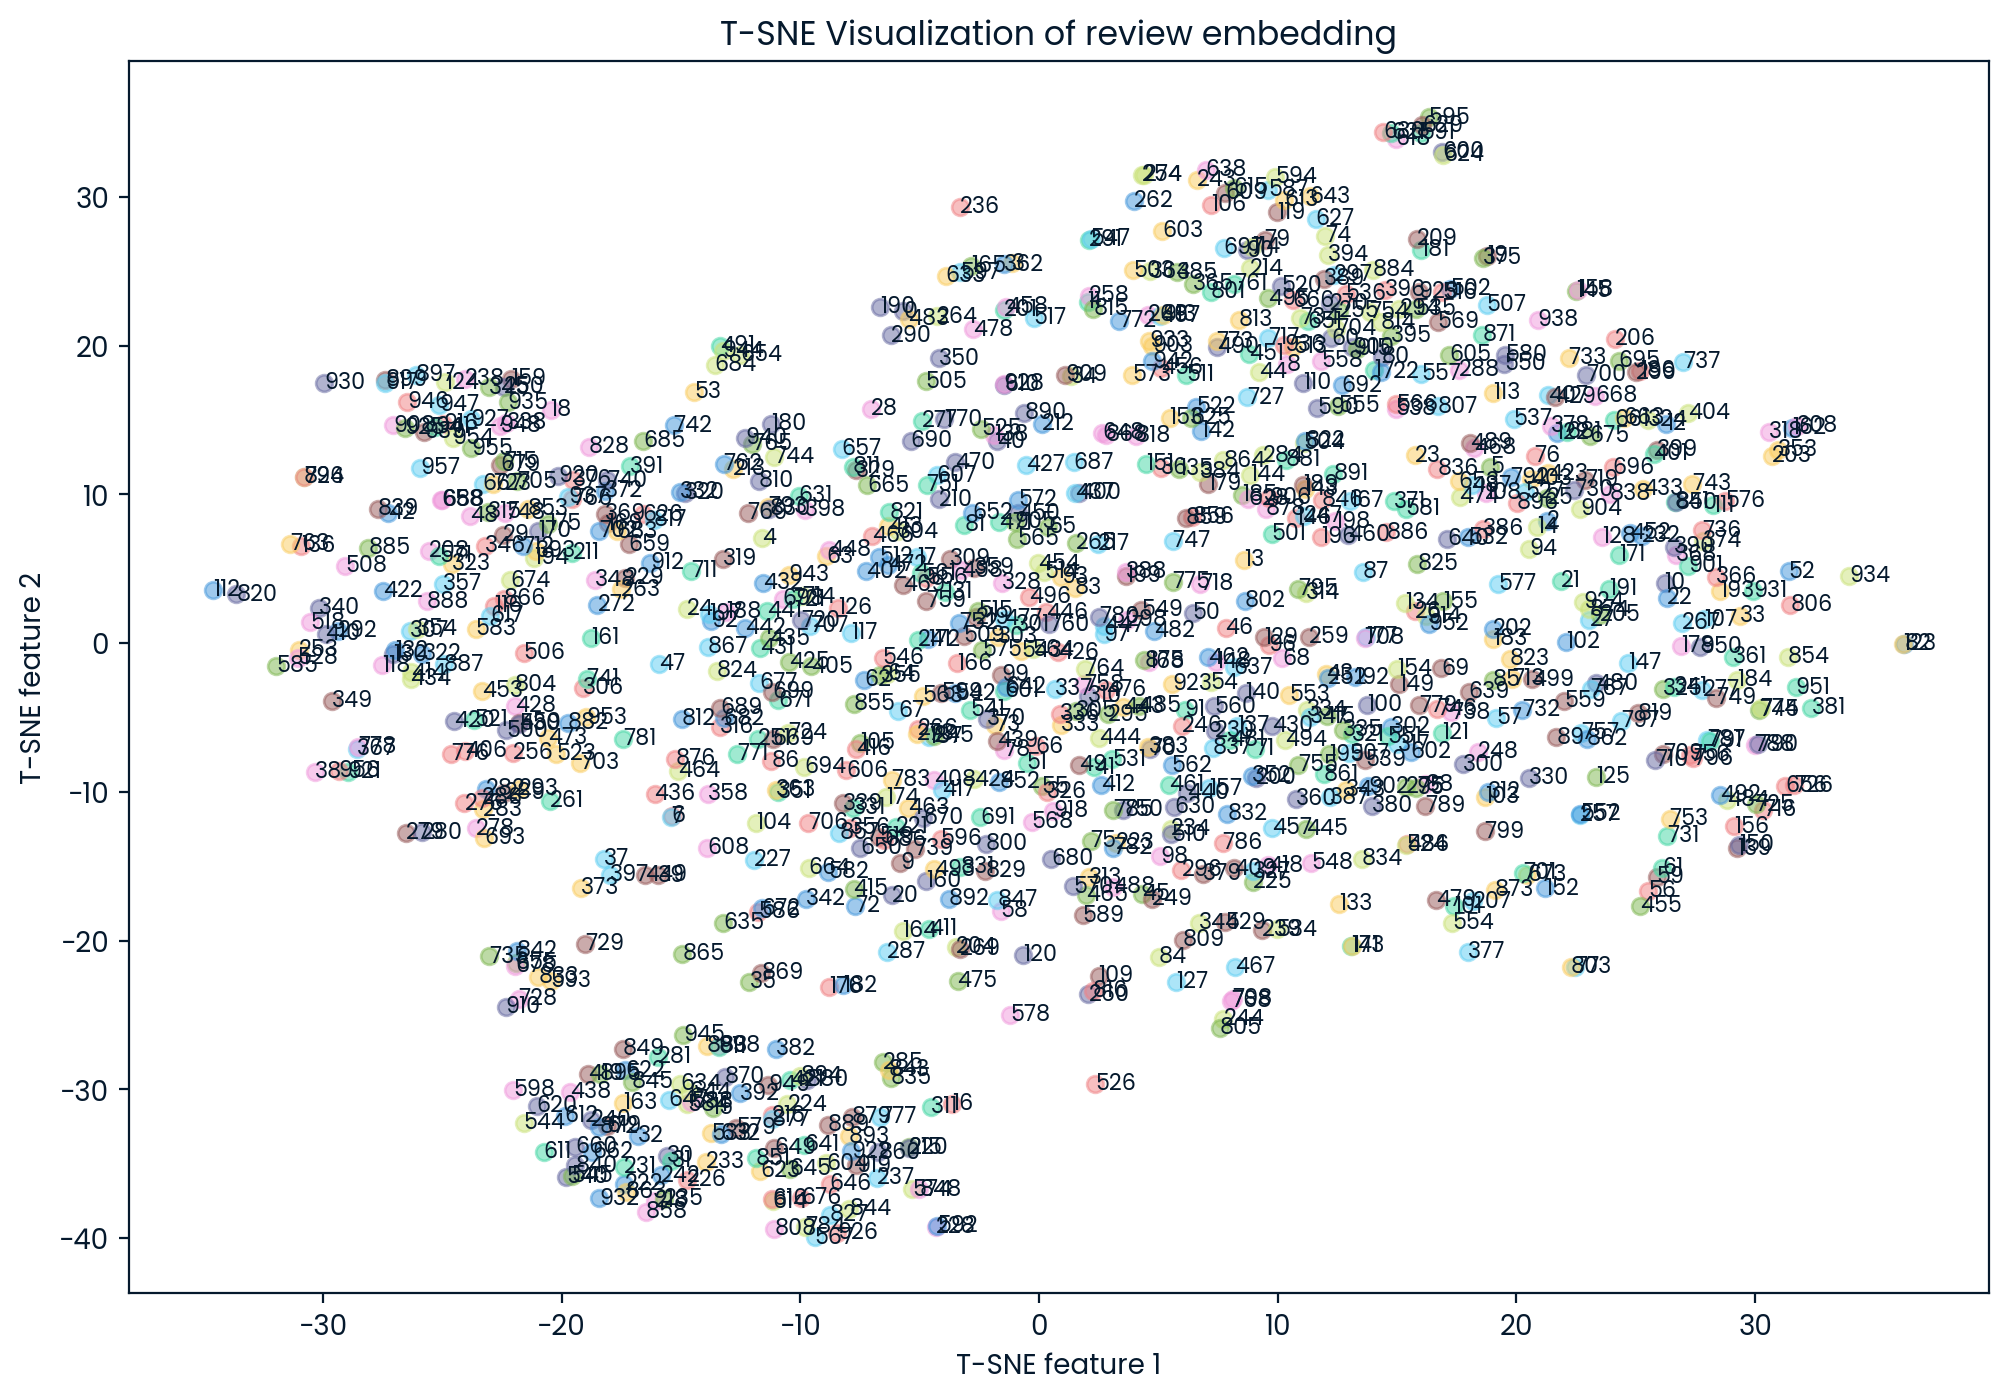

In [54]:
# Reducing the dimensionality and visualizing in a plot

from sklearn.manifold import TSNE
import numpy as np

def apply_tsne(embeddings):
    tsne=TSNE(n_components=2,random_state=0)
    return tsne.fit_transform(np.array(embeddings))

embeddings_2d=apply_tsne(embeddings)    

# to visualize clusters or patterns in the data.

import matplotlib.pyplot as plt

def plot_tsne(tsne_results):
    plt.figure(figsize=(12,8))
    for i, point in enumerate(tsne_results):
        plt.scatter(point[0], point[1], alpha=0.5)
        plt.text(point[0],point[1], str(i), fontsize=8, verticalalignment='center')
    plt.title("T-SNE Visualization of review embedding")
    plt.xlabel("T-SNE feature 1")
    plt.ylabel("T-SNE feature 2")

    plt.show()

plot_tsne(embeddings_2d)




In [55]:
import chromadb
import os
from scipy.spatial import distance
from chromadb.utils.embedding_functions import OpenAIEmbeddingFunction

categories = ['quality', 'fit', 'style', 'comfort']

# Make sure EMBEDDING_MODEL and embeddings, review_text are defined elsewhere in your notebook

client = chromadb.PersistentClient()

# Fix: Use get_or_create=True to avoid UniqueConstraintError if collection exists
review_embedding_db = client.create_collection(
    name='review_embeddings',
    embedding_function=OpenAIEmbeddingFunction(model_name='text-embedding-3-small', api_key=os.environ["OPENAI_API_KEY"]),
    get_or_create=True
)

# Only add documents if the collection is empty (avoid duplicate ids)
if review_embedding_db.count() == 0:
    review_embedding_db.add(
        documents=review_text.tolist(),
        ids=[str(i) for i in range(len(review_text))]
    )

# --- FIX STARTS HERE ---
# Use the embedding function directly to get category embeddings
embedding_fn = OpenAIEmbeddingFunction(model_name='text-embedding-3-small', api_key=os.environ["OPENAI_API_KEY"])
categories_embeddings = embedding_fn(categories)
# --- FIX ENDS HERE ---

def categorise_feedback(text_embedding, categories_embeddings):
    similarities = [{'distance': distance.cosine(text_embedding, cat_emb), 'index': i} for i, cat_emb in enumerate(categories_embeddings)]
    closest = min(similarities, key=lambda x: x['distance'])
    return categories[closest['index']]

feedback_categories = [categorise_feedback(embedding, categories_embeddings) for embedding in embeddings]

def find_similar_review(input_text, vector_db, n=3):
    # Use the existing collection, don't recreate
    results = vector_db.query(
        query_texts=[input_text],
        n_results=n        
    )
    return results

example_review = "Absolutely wonderful - silky and sexy and comfortable"
most_similar_reviews = find_similar_review(example_review, review_embedding_db, 3)["documents"][0]
print(most_similar_reviews)

# Optional: Clean up collection at the end if desired
client.delete_collection(name='review_embeddings')

['Absolutely wonderful - silky and sexy and comfortable', 'Very comfortable and versatile. got lots of compliments.', 'This is a very comfortable and sexy sleep dress, the way it drapes. i can see that the type of fabric is not suitable for out and about activities and can catch on snags, etc. very easily. once i relegated it to the nightgown category it became my favorite item to wear and lounge in.']
